In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
df = pd.DataFrame({
    'X1' : [3,2,1,5,4,9,6],
    'X2' : [7,4,6,8,9,3,1],
    'Y' :  [0,1,0,1,0,1,1]
})

In [48]:
df

,X1,X2,Y
0,3,7,0
1,2,4,1
2,1,6,0
3,5,8,1
4,4,9,0
5,9,3,1
6,6,1,1


<Axes: xlabel='X1', ylabel='X2'>

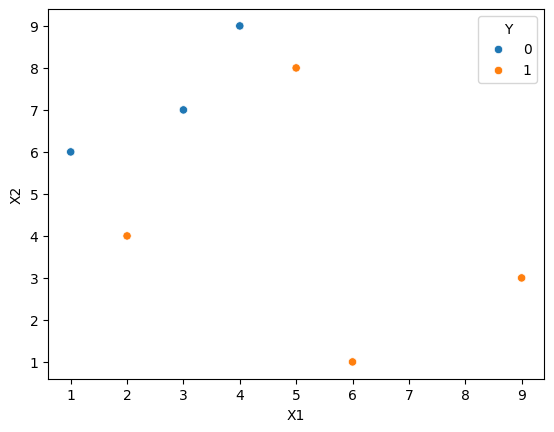

In [49]:
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')

In [50]:
df['weight'] = 1/df.shape[0]

In [51]:
df

,X1,X2,Y,weight
0,3,7,0,0.142857
1,2,4,1,0.142857
2,1,6,0,0.142857
3,5,8,1,0.142857
4,4,9,0,0.142857
5,9,3,1,0.142857
6,6,1,1,0.142857


In [52]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1)
dt1.fit(df[['X1','X2']],df['Y'])

DecisionTreeClassifier(max_depth=1)

In [53]:
df['Y_pred'] = dt1.predict(df[['X1','X2']])

In [54]:
df

,X1,X2,Y,weight,Y_pred
0,3,7,0,0.142857,0
1,2,4,1,0.142857,1
2,1,6,0,0.142857,0
3,5,8,1,0.142857,0
4,4,9,0,0.142857,0
5,9,3,1,0.142857,1
6,6,1,1,0.142857,1


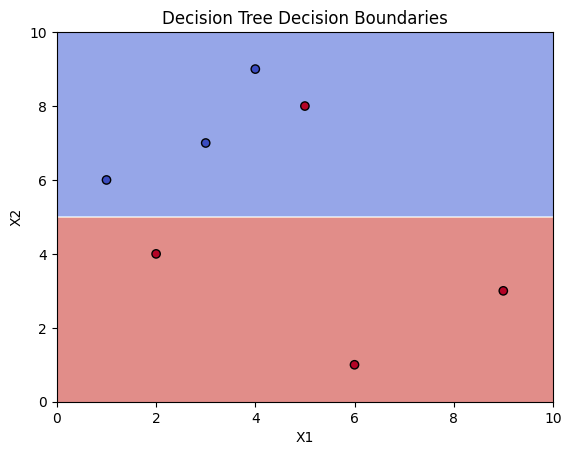

In [55]:
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    dt1,
    df[['X1','X2']],
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.6,
    xlabel='X1',
    ylabel='X2',
)

disp.ax_.scatter(df['X1'], df['X2'], c=df['Y'], edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("Decision Tree Decision Boundaries")
plt.show()

In [56]:
def calculate_alpha(error):
  alpha = 1/2 * (np.log((1-error)/error+0.0001))
  return alpha

In [57]:
alpha1 = calculate_alpha(0.142857)
print(alpha1)

0.8958886512017714


In [58]:
def update_weight(row,alpha = 0.895):
  if row['Y'] == row['Y_pred']:
    return row['weight'] * np.exp(-alpha)
  else:
    return row['weight'] * np.exp(alpha)

In [59]:
df['update_weight'] = df.apply(update_weight,axis=1)

In [60]:
df

,X1,X2,Y,weight,Y_pred,update_weight
0,3,7,0,0.142857,0,0.058373
1,2,4,1,0.142857,1,0.058373
2,1,6,0,0.142857,0,0.058373
3,5,8,1,0.142857,0,0.349619
4,4,9,0,0.142857,0,0.058373
5,9,3,1,0.142857,1,0.058373
6,6,1,1,0.142857,1,0.058373


In [61]:
df['normalized_weight'] = df['update_weight']/df['update_weight'].sum()

In [62]:
df

,X1,X2,Y,weight,Y_pred,update_weight,normalized_weight
0,3,7,0,0.142857,0,0.058373,0.083407
1,2,4,1,0.142857,1,0.058373,0.083407
2,1,6,0,0.142857,0,0.058373,0.083407
3,5,8,1,0.142857,0,0.349619,0.499560
4,4,9,0,0.142857,0,0.058373,0.083407
5,9,3,1,0.142857,1,0.058373,0.083407
6,6,1,1,0.142857,1,0.058373,0.083407


In [63]:
df['cumsum_upper'] = np.cumsum(df['normalized_weight'])

In [64]:
df['cumsum_lower']= df['cumsum_upper'] - df['normalized_weight']

In [65]:
df

,X1,X2,Y,weight,Y_pred,update_weight,normalized_weight,cumsum_upper,cumsum_lower
0,3,7,0,0.142857,0,0.058373,0.083407,0.083407,0.000000
1,2,4,1,0.142857,1,0.058373,0.083407,0.166813,0.083407
2,1,6,0,0.142857,0,0.058373,0.083407,0.250220,0.166813
3,5,8,1,0.142857,0,0.349619,0.499560,0.749780,0.250220
4,4,9,0,0.142857,0,0.058373,0.083407,0.833187,0.749780
5,9,3,1,0.142857,1,0.058373,0.083407,0.916593,0.833187
6,6,1,1,0.142857,1,0.058373,0.083407,1.000000,0.916593


In [66]:
def create_new_dataset(df):
  indicies = []

  for i in range(df.shape[0]):
    num = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_lower'] < num and num < row['cumsum_upper']:
        indicies.append(index)
  return indicies

In [67]:
index_values = create_new_dataset(df)
index_values

[3, 3, 0, 5, 3, 3, 5]

In [68]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [69]:
second_df

,X1,X2,Y,weight
3,5,8,1,0.142857
3,5,8,1,0.142857
0,3,7,0,0.142857
5,9,3,1,0.142857
3,5,8,1,0.142857
3,5,8,1,0.142857
5,9,3,1,0.142857


In [70]:
dt2 = DecisionTreeClassifier(max_depth=1)
dt2.fit(second_df[['X1','X2']],second_df['Y'])

DecisionTreeClassifier(max_depth=1)

In [71]:
second_df['Y_pred'] = dt2.predict(second_df[['X1','X2']])

In [72]:
second_df

,X1,X2,Y,weight,Y_pred
3,5,8,1,0.142857,1
3,5,8,1,0.142857,1
0,3,7,0,0.142857,0
5,9,3,1,0.142857,1
3,5,8,1,0.142857,1
3,5,8,1,0.142857,1
5,9,3,1,0.142857,1


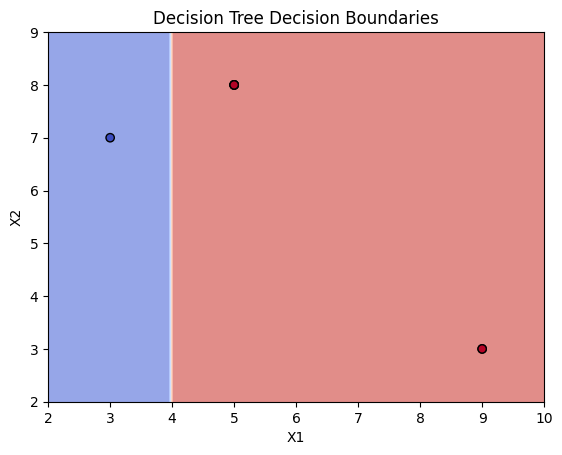

In [73]:
disp = DecisionBoundaryDisplay.from_estimator(
    dt2,
    second_df[['X1','X2']],
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.6,
    xlabel='X1',
    ylabel='X2',
)

disp.ax_.scatter(second_df['X1'], second_df['X2'], c=second_df['Y'], edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("Decision Tree Decision Boundaries")
plt.show()

In [75]:
alpha2 = calculate_alpha(1e-10)

In [76]:
alpha2

np.float64(11.512925464920233)

In [77]:
second_df['Update_weight'] = second_df.apply(update_weight,axis=1)

In [78]:
second_df

,X1,X2,Y,weight,Y_pred,Update_weight
3,5,8,1,0.142857,1,0.058373
3,5,8,1,0.142857,1,0.058373
0,3,7,0,0.142857,0,0.058373
5,9,3,1,0.142857,1,0.058373
3,5,8,1,0.142857,1,0.058373
3,5,8,1,0.142857,1,0.058373
5,9,3,1,0.142857,1,0.058373


In [79]:
second_df['normalized_weight'] = second_df['Update_weight']/second_df['Update_weight'].sum()

In [80]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weight'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weight']

In [82]:
index_values2 = create_new_dataset(second_df)
index_values2

[3, 3, 5, 0, 0, 0, 3]

In [88]:
third_df = second_df.iloc[index_values2,[0,1,2,3]]

In [89]:
third_df

,X1,X2,Y,weight
5,9,3,1,0.142857
5,9,3,1,0.142857
3,5,8,1,0.142857
3,5,8,1,0.142857
3,5,8,1,0.142857
3,5,8,1,0.142857
5,9,3,1,0.142857


In [90]:
dt3 = DecisionTreeClassifier(max_depth=1)
dt3.fit(third_df[['X1','X2']],third_df['Y'])

DecisionTreeClassifier(max_depth=1)

In [92]:
third_df['Y_pred'] = dt3.predict(third_df[['X1','X2']])

In [93]:
third_df

,X1,X2,Y,weight,Y_pred
5,9,3,1,0.142857,1
5,9,3,1,0.142857,1
3,5,8,1,0.142857,1
3,5,8,1,0.142857,1
3,5,8,1,0.142857,1
3,5,8,1,0.142857,1
5,9,3,1,0.142857,1


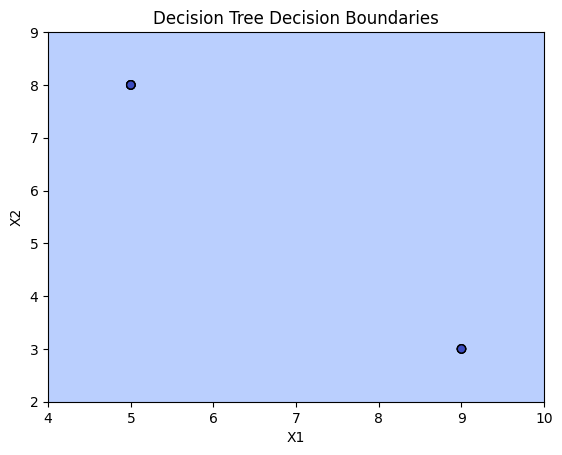

In [94]:
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    dt3,
    third_df[['X1','X2']],
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.6,
    xlabel='X1',
    ylabel='X2',
)

disp.ax_.scatter(third_df['X1'], third_df['X2'], c=third_df['Y'], edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("Decision Tree Decision Boundaries")
plt.show()

In [95]:
alpha3 = calculate_alpha(1e-10)

In [97]:
alpha3

np.float64(11.512925464920233)

In [98]:
third_df['update_weight'] = third_df.apply(update_weight,axis=1)

In [99]:
third_df['normalized_weight'] = third_df['update_weight']/third_df['update_weight'].sum()

In [100]:
third_df

,X1,X2,Y,weight,Y_pred,update_weight,normalized_weight
5,9,3,1,0.142857,1,0.058373,0.142857
5,9,3,1,0.142857,1,0.058373,0.142857
3,5,8,1,0.142857,1,0.058373,0.142857
3,5,8,1,0.142857,1,0.058373,0.142857
3,5,8,1,0.142857,1,0.058373,0.142857
3,5,8,1,0.142857,1,0.058373,0.142857
5,9,3,1,0.142857,1,0.058373,0.142857


In [102]:
third_df['cumsum_upper'] = np.cumsum(third_df['normalized_weight'])
third_df['cumsum_lower'] = third_df['cumsum_upper'] - third_df['normalized_weight']

In [103]:
index_values3 = create_new_dataset(third_df)
index_values3

[3, 3, 5, 5, 3, 3, 5]

In [112]:
query = np.array([5,8]).reshape(1,2)
p1 = dt1.predict(query)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [113]:
query = np.array([5,8]).reshape(1,2)
p2 = dt2.predict(query)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [114]:
query = np.array([5,8]).reshape(1,2)
p3 = dt3.predict(query)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [115]:
predict = (alpha1*p1)+(alpha2*p2)+(alpha3*p3)
if predict > 0:
  print("1")
else :
  print("0")

1
